In [10]:
# ============================================================
# SCM-A2G-QFL RESULT ANALYSIS NOTEBOOK BLOCK
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PAPER-READY PLOT STYLE SETTINGS
# ============================================================
PLOT_FIGSIZE = (5, 4)
PLOT_FONT_SIZE = 16

plt.rcParams.update({
    "font.size": PLOT_FONT_SIZE,
    "axes.titlesize": PLOT_FONT_SIZE,
    "axes.labelsize": PLOT_FONT_SIZE,
    "xtick.labelsize": PLOT_FONT_SIZE,
    "ytick.labelsize": PLOT_FONT_SIZE,
    "legend.fontsize": 14,
    "figure.titlesize": PLOT_FONT_SIZE,
})


# ============================================================
# 1. USER SETTINGS
# ============================================================

RUNS_DIR = Path(
    r"C:\Users\s222112938\OneDrive - Deakin University\Ph.D\MyPublication\A2G_Journal_Version\SCMResults\runs\lesions_med_depolarizing"
)

SCHEMES_TO_ANALYSE = [
    "Journal_SCM_beta010_relax07",
    "Journal_SCM_beta015_relax07",
    "Journal_SCM_beta020_relax07",
    "Journal_SCM_A2G_QFLbeta005",
    #"Journal_MP_A2G_QFL_v1",
    #"FedAvg",
    #"Conf_A2G_Circular",
    "Journal_SCM_beta02",
    "Journal_SCM_beta003",
    "Journal_SCM_beta008",
    "Journal_SCM_beta020_relax10",
    "Journal_SCM_softQoS_beta005",
    "Journal_SCM_softQoS_beta008",
]
  

METHOD_LABELS = {
    # Main baselines
    "FedAvg": "FedAvg",
    "Conf_A2G_Circular": "A2G",
    "Journal_MP_A2G_QFL_v1": "MP-A2G",

    # SCM beta tuning
    "Journal_SCM_beta003": r"$\beta=0.03$",
    "Journal_SCM_beta008": r"$\beta=0.08$",
    "Journal_SCM_beta010_relax07": r"$\beta=0.10$,$\omega=0.7$",
    "Journal_SCM_beta015_relax07": r"$\beta=0.15$,$\omega=0.7$",
    "Journal_SCM_beta020_relax07": r"$\beta=0.20$, $\omega=0.7$",
    "Journal_SCM_beta020_relax10": r"$\beta=0.20$, $\omega=1.0$",

    # If beta02 means beta = 0.20, use this
    "Journal_SCM_beta02": r"SCM $\beta=0.20$",

    # A2G/SCM hybrid naming
    "Journal_SCM_A2G_QFLbeta005": r"$\beta=0.05$",

    # Soft QoS variants
    "Journal_SCM_softQoS_beta005": r"soft-QoS $\beta=0.05$",
    "Journal_SCM_softQoS_beta008": r"soft-QoS $\beta=0.08$",
}

METHOD_COLORS = {
    "FedAvg": "tab:orange",
    "Conf_A2G_Circular": "tab:blue",
    "Journal_MP_A2G_QFL_v1": "tab:green",

    "Journal_SCM_beta003": "tab:pink",
    "Journal_SCM_beta008": "tab:brown",
    "Journal_SCM_beta010_relax07": "tab:purple",
    "Journal_SCM_beta015_relax07": "tab:red",
    "Journal_SCM_beta020_relax07": "tab:olive",
    "Journal_SCM_beta020_relax10": "tab:cyan",
    "Journal_SCM_beta02": "tab:olive",

    "Journal_SCM_A2G_QFLbeta005": "tab:gray",
    "Journal_SCM_softQoS_beta005": "goldenrod",
    "Journal_SCM_softQoS_beta008": "darkkhaki",
}

METHOD_MARKERS = {
    "FedAvg": "o",
    "Conf_A2G_Circular": "s",
    "Journal_MP_A2G_QFL_v1": "^",
    "Journal_SCM_beta010_relax07": "D",
    "Journal_SCM_beta015_relax07": "D",
    "Journal_SCM_beta020_relax10": "P",
}


SEEDS = [100, 200, 300, 400, 500]

OUT_DIR = RUNS_DIR / "scm_tuning_only"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MIN_EPOCHS_REQUIRED = 1   # use 20 later if you want only complete runs

print("RUNS_DIR:", RUNS_DIR)
print("Exists:", RUNS_DIR.exists())
print("Output:", OUT_DIR)

RUNS_DIR: C:\Users\s222112938\OneDrive - Deakin University\Ph.D\MyPublication\A2G_Journal_Version\SCMResults\runs\lesions_med_depolarizing
Exists: True
Output: C:\Users\s222112938\OneDrive - Deakin University\Ph.D\MyPublication\A2G_Journal_Version\SCMResults\runs\lesions_med_depolarizing\scm_tuning_only


In [11]:
# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================

def tcrit_95(n: int) -> float:
    table = {
        2: 12.706, 3: 4.303, 4: 3.182, 5: 2.776,
        6: 2.571, 7: 2.447, 8: 2.365, 9: 2.306, 10: 2.262
    }
    return table.get(int(n), 1.96)


def mean_ci95(values):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    n = len(values)

    if n == 0:
        return np.nan, np.nan
    if n == 1:
        return float(np.mean(values)), 0.0

    mean = float(np.mean(values))
    ci = float(tcrit_95(n) * np.std(values, ddof=1) / np.sqrt(n))
    return mean, ci


def read_csv_if_exists(path: Path):
    if path.exists():
        return pd.read_csv(path)
    return None


def read_curve(run_dir: Path):
    """
    Prefer curve.csv. If missing, use round.csv global_acc.
    """
    curve_path = run_dir / "curve.csv"
    round_path = run_dir / "round.csv"

    if curve_path.exists():
        df = pd.read_csv(curve_path)
        source = "curve.csv"
    elif round_path.exists():
        df = pd.read_csv(round_path)
        source = "round.csv"
    else:
        return None, None

    if "global_acc" in df.columns:
        acc = df["global_acc"].astype(float).to_numpy()
    elif "GlobalAccuracy" in df.columns:
        acc = df["GlobalAccuracy"].astype(float).to_numpy()
    else:
        num_cols = df.select_dtypes(include=[np.number]).columns
        acc = df[num_cols[-1]].astype(float).to_numpy()

    return acc, source


def safe_numeric_mean(df, col):
    if df is None or col not in df.columns:
        return np.nan
    return float(pd.to_numeric(df[col], errors="coerce").mean())


def safe_numeric_tail_mean(df, col, k=5):
    if df is None or col not in df.columns:
        return np.nan
    return float(pd.to_numeric(df[col], errors="coerce").tail(k).mean())


def safe_numeric_std(df, col):
    if df is None or col not in df.columns:
        return np.nan
    vals = pd.to_numeric(df[col], errors="coerce").dropna()
    if len(vals) <= 1:
        return 0.0
    return float(vals.std(ddof=1))


def safe_numeric_max(df, col):
    if df is None or col not in df.columns:
        return np.nan
    return float(pd.to_numeric(df[col], errors="coerce").max())


def safe_numeric_min(df, col):
    if df is None or col not in df.columns:
        return np.nan
    return float(pd.to_numeric(df[col], errors="coerce").min())

In [12]:
# ============================================================
# 3. LOAD ALL RUNS AND CREATE summary_by_seed.csv
# ============================================================

curve_rows = []
validation_rows = []
round_rows = []
summary_rows = []
missing_rows = []

diagnostic_cols = [
    "update_norm",
    "manifold_dispersion",
    "weight_entropy",
    "beta",
    "beta_raw",
    "beta_eff",
    "midpoint_shift_norm",
    "projection_shift_norm",
    "tangent_norm",
    "v_mid_norm",
    "scm_residual",
    "scm_implied_gain",
    "scm_direction_alignment",
    "scm_midpoint_dispersion",
    "scm_iters",
    "scm_converged",
]

for scheme in SCHEMES_TO_ANALYSE:
    for seed in SEEDS:
        run_dir = RUNS_DIR / scheme / f"seed_{seed}"

        if not run_dir.exists():
            missing_rows.append({
                "scheme": scheme,
                "seed": seed,
                "reason": "missing seed folder",
                "path": str(run_dir),
            })
            continue

        acc, curve_source = read_curve(run_dir)

        if acc is None:
            missing_rows.append({
                "scheme": scheme,
                "seed": seed,
                "reason": "missing curve.csv and round.csv",
                "path": str(run_dir),
            })
            continue

        if len(acc) < MIN_EPOCHS_REQUIRED:
            missing_rows.append({
                "scheme": scheme,
                "seed": seed,
                "reason": f"only {len(acc)} epochs",
                "path": str(run_dir),
            })
            continue

        # ----------------------------
        # Accuracy curve rows
        # ----------------------------
        for epoch, a in enumerate(acc):
            curve_rows.append({
                "scheme": scheme,
                "seed": seed,
                "epoch": int(epoch),
                "global_acc": float(a),
                "source": curve_source,
            })

        # ----------------------------
        # Basic seed-level accuracy metrics
        # ----------------------------
        T = len(acc)
        init_acc = float(acc[0])
        final_acc = float(acc[-1])
        best_acc = float(np.max(acc))
        best_epoch_acc = int(np.argmax(acc))
        last5 = acc[-5:] if T >= 5 else acc
        first5 = acc[:5] if T >= 5 else acc

        auc_all = float(np.trapezoid(acc, dx=1) / max(T - 1, 1))
        auc_first5 = float(np.mean(first5))
        last5_mean = float(np.mean(last5))
        last5_std = float(np.std(last5, ddof=1)) if len(last5) > 1 else 0.0
        drop_from_best = float(best_acc - final_acc)

        diffs = np.diff(acc)
        monotonicity = float(np.mean(diffs >= 0)) if len(diffs) > 0 else np.nan

        summary = {
            "scheme": scheme,
            "seed": seed,
            "num_epochs_loaded": T,
            "curve_source": curve_source,
            "init_acc": init_acc,
            "final_acc": final_acc,
            "best_acc": best_acc,
            "best_epoch_acc": best_epoch_acc,
            "last5_mean": last5_mean,
            "last5_std": last5_std,
            "auc_all": auc_all,
            "auc_first5": auc_first5,
            "gain_final": final_acc - init_acc,
            "gain_best": best_acc - init_acc,
            "drop_from_best": drop_from_best,
            "monotonicity": monotonicity,
        }

        # ----------------------------
        # Validation curve
        # ----------------------------
        val_df = read_csv_if_exists(run_dir / "validation_curve.csv")
        if val_df is not None:
            val_df = val_df.copy()
            val_df["scheme"] = scheme
            val_df["seed"] = seed
            validation_rows.append(val_df)

            if "val_loss" in val_df.columns:
                val_loss = pd.to_numeric(val_df["val_loss"], errors="coerce")
                best_val_idx = int(val_loss.idxmin())
                summary["best_val_loss_from_curve"] = float(val_df.loc[best_val_idx, "val_loss"])
                summary["best_val_epoch_from_curve"] = int(val_df.loc[best_val_idx, "epoch"])

                if "val_acc" in val_df.columns:
                    summary["val_acc_at_best_val_loss"] = float(val_df.loc[best_val_idx, "val_acc"])

                if "test_acc_current" in val_df.columns:
                    summary["test_acc_at_best_val_loss"] = float(val_df.loc[best_val_idx, "test_acc_current"])

                if "test_loss_current" in val_df.columns:
                    summary["test_loss_at_best_val_loss"] = float(val_df.loc[best_val_idx, "test_loss_current"])

            if "val_acc" in val_df.columns:
                val_acc = pd.to_numeric(val_df["val_acc"], errors="coerce")
                best_val_acc_idx = int(val_acc.idxmax())
                summary["best_val_acc_from_curve"] = float(val_df.loc[best_val_acc_idx, "val_acc"])
                summary["best_val_acc_epoch_from_curve"] = int(val_df.loc[best_val_acc_idx, "epoch"])
                if "val_loss" in val_df.columns:
                    summary["val_loss_at_best_val_acc"] = float(val_df.loc[best_val_acc_idx, "val_loss"])
                if "test_acc_current" in val_df.columns:
                    summary["test_acc_at_best_val_acc"] = float(val_df.loc[best_val_acc_idx, "test_acc_current"])

        # ----------------------------
        # Selected checkpoint summary
        # ----------------------------
        selected_df = read_csv_if_exists(run_dir / "selected_checkpoint_summary.csv")
        if selected_df is not None and len(selected_df) > 0:
            row = selected_df.iloc[0].to_dict()

            for col in [
                "selected_epoch",
                "best_val_acc",
                "best_val_loss",
                "selected_test_acc",
                "selected_test_loss",
                "final_epoch",
                "stationary_epoch",
            ]:
                if col in row:
                    summary[col] = row[col]

        # ----------------------------
        # Round telemetry
        # ----------------------------
        r_df = read_csv_if_exists(run_dir / "round.csv")
        if r_df is not None:
            r_df = r_df.copy()
            r_df["scheme"] = scheme
            r_df["seed"] = seed
            round_rows.append(r_df)

            for col in diagnostic_cols:
                if col in r_df.columns:
                    summary[f"mean_{col}"] = safe_numeric_mean(r_df, col)
                    summary[f"last5_{col}"] = safe_numeric_tail_mean(r_df, col, k=5)
                    summary[f"std_{col}"] = safe_numeric_std(r_df, col)
                    summary[f"max_{col}"] = safe_numeric_max(r_df, col)
                    summary[f"min_{col}"] = safe_numeric_min(r_df, col)

                    if col == "update_norm":
                        values = pd.to_numeric(r_df[col], errors="coerce").dropna()
                        summary["cumulative_update_norm"] = float(values.sum()) if len(values) else np.nan

        summary_rows.append(summary)

curves_df = pd.DataFrame(curve_rows)
validation_df = pd.concat(validation_rows, ignore_index=True) if validation_rows else pd.DataFrame()
rounds_df = pd.concat(round_rows, ignore_index=True) if round_rows else pd.DataFrame()
summary_by_seed = pd.DataFrame(summary_rows)
missing_df = pd.DataFrame(missing_rows)

summary_by_seed.to_csv(OUT_DIR / "summary_by_seed.csv", index=False)
curves_df.to_csv(OUT_DIR / "all_accuracy_curves_long.csv", index=False)
validation_df.to_csv(OUT_DIR / "all_validation_curves_long.csv", index=False)
rounds_df.to_csv(OUT_DIR / "all_round_telemetry_long.csv", index=False)
missing_df.to_csv(OUT_DIR / "missing_runs_report.csv", index=False)

print("summary_by_seed:")
display(summary_by_seed)

print("Missing:")
display(missing_df)

summary_by_seed:


,scheme,seed,num_epochs_loaded,curve_source,init_acc,final_acc,best_acc,best_epoch_acc,last5_mean,last5_std,...,mean_tangent_norm,last5_tangent_norm,std_tangent_norm,max_tangent_norm,min_tangent_norm,mean_v_mid_norm,last5_v_mid_norm,std_v_mid_norm,max_v_mid_norm,min_v_mid_norm
0,Journal_SCM_beta010_relax07,100,20,curve.csv,0.523810,0.539683,0.714286,14,0.565079,0.032915,...,2.792345,2.594269,0.608472,3.913021,1.817041,2.659344,2.470702,0.579490,3.726640,1.730494
1,Journal_SCM_beta010_relax07,200,20,curve.csv,0.523810,0.555556,0.619048,6,0.536508,0.020696,...,2.336558,1.868074,0.697168,3.707809,1.276262,2.225266,1.779096,0.663961,3.531203,1.215473
2,Journal_SCM_beta010_relax07,300,20,curve.csv,0.523810,0.555556,0.619048,10,0.558730,0.020696,...,2.514737,2.694450,0.550306,3.668392,1.884518,2.425955,2.566111,0.504702,3.493663,1.820460
3,Journal_SCM_beta010_relax07,400,20,curve.csv,0.523810,0.476190,0.571429,6,0.501587,0.018098,...,2.443745,2.344609,0.591889,3.433096,1.333838,2.327347,2.232934,0.563697,3.269574,1.270306
4,Journal_SCM_beta010_relax07,500,20,curve.csv,0.539683,0.539683,0.619048,11,0.577778,0.026561,...,2.854124,2.484602,0.432556,3.994246,2.252927,2.728583,2.366259,0.418150,3.803997,2.145618
5,Journal_SCM_beta015_relax07,100,20,curve.csv,0.539683,0.666667,0.682540,7,0.641270,0.036542,...,2.516956,2.126454,0.464832,3.359458,1.706511,2.365137,1.978055,0.438932,3.125011,1.587419
6,Journal_SCM_beta015_relax07,200,20,curve.csv,0.539683,0.492063,0.634921,3,0.523810,0.025097,...,2.600399,2.508195,0.476343,3.457790,1.890708,2.450406,2.333155,0.430387,3.216481,1.758761
7,Journal_SCM_beta015_relax07,300,20,curve.csv,0.507937,0.492063,0.587302,5,0.514286,0.021296,...,2.632987,2.654690,0.500308,3.496393,1.750164,2.462211,2.521315,0.487026,3.339895,1.628025
8,Journal_SCM_beta015_relax07,400,20,curve.csv,0.476190,0.603175,0.650794,3,0.634921,0.019440,...,2.523948,1.979469,0.647972,3.447289,1.455372,2.347809,1.841328,0.602752,3.206713,1.353806
9,Journal_SCM_beta015_relax07,500,20,curve.csv,0.476190,0.571429,0.619048,3,0.555556,0.011224,...,2.604378,2.761758,0.610880,3.717987,1.358752,2.422626,2.569023,0.568248,3.458519,1.263928


Missing:


,scheme,seed,reason,path
0,Journal_SCM_softQoS_beta008,400,missing seed folder,C:\Users\s222112938\OneDrive - Deakin Universi...
1,Journal_SCM_softQoS_beta008,500,missing seed folder,C:\Users\s222112938\OneDrive - Deakin Universi...


In [13]:
# ============================================================
# 4. METHOD-LEVEL SUMMARY: mean ± CI, median/IQR
# ============================================================

def aggregate_method_summary(summary_by_seed: pd.DataFrame):
    rows = []

    metric_cols = [
        c for c in summary_by_seed.columns
        if c not in ["scheme", "seed", "curve_source"]
        and pd.api.types.is_numeric_dtype(summary_by_seed[c])
    ]

    for scheme, g in summary_by_seed.groupby("scheme"):
        row = {
            "scheme": scheme,
            "n_seeds": g["seed"].nunique(),
        }

        for col in metric_cols:
            values = pd.to_numeric(g[col], errors="coerce").dropna().to_numpy()
            if len(values) == 0:
                continue

            mean, ci = mean_ci95(values)

            row[f"{col}_mean"] = mean
            row[f"{col}_ci95"] = ci
            row[f"{col}_median"] = float(np.median(values))
            row[f"{col}_q1"] = float(np.percentile(values, 25))
            row[f"{col}_q3"] = float(np.percentile(values, 75))

        rows.append(row)

    out = pd.DataFrame(rows)
    return out


method_summary = aggregate_method_summary(summary_by_seed)
method_summary.to_csv(OUT_DIR / "method_summary_mean_ci_median_iqr.csv", index=False)

display(method_summary)

,scheme,n_seeds,num_epochs_loaded_mean,num_epochs_loaded_ci95,num_epochs_loaded_median,num_epochs_loaded_q1,num_epochs_loaded_q3,init_acc_mean,init_acc_ci95,init_acc_median,...,selected_test_loss_mean,selected_test_loss_ci95,selected_test_loss_median,selected_test_loss_q1,selected_test_loss_q3,final_epoch_mean,final_epoch_ci95,final_epoch_median,final_epoch_q1,final_epoch_q3
0,Journal_SCM_A2G_QFLbeta005,5,20.0,0.000,20.0,20.0,20.0,0.520635,0.016487,0.523810,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Journal_SCM_beta003,5,20.0,0.000,20.0,20.0,20.0,0.517460,0.022468,0.523810,...,0.714326,0.008838,0.713985,0.708487,0.715187,19.0,0.0,19.0,19.0,19.0
2,Journal_SCM_beta008,5,20.0,0.000,20.0,20.0,20.0,0.514286,0.017625,0.523810,...,0.714392,0.027801,0.725515,0.714490,0.728099,19.0,0.0,19.0,19.0,19.0
3,Journal_SCM_beta010_relax07,5,20.0,0.000,20.0,20.0,20.0,0.526984,0.008813,0.523810,...,0.711325,0.016603,0.710979,0.703549,0.719190,19.0,0.0,19.0,19.0,19.0
4,Journal_SCM_beta015_relax07,5,20.0,0.000,20.0,20.0,20.0,0.507937,0.039412,0.507937,...,0.697505,0.027979,0.699329,0.690760,0.705843,19.0,0.0,19.0,19.0,19.0
5,Journal_SCM_beta02,5,20.0,0.000,20.0,20.0,20.0,0.530159,0.061689,0.555556,...,0.699937,0.012074,0.697000,0.692270,0.708412,19.0,0.0,19.0,19.0,19.0
6,Journal_SCM_beta020_relax07,5,20.0,0.000,20.0,20.0,20.0,0.533333,0.049461,0.555556,...,0.707174,0.024815,0.710450,0.703438,0.718508,19.0,0.0,19.0,19.0,19.0
7,Journal_SCM_beta020_relax10,5,20.0,0.000,20.0,20.0,20.0,0.523810,0.057452,0.539683,...,0.696546,0.019919,0.703437,0.680795,0.709736,19.0,0.0,19.0,19.0,19.0
8,Journal_SCM_softQoS_beta005,5,20.0,0.000,20.0,20.0,20.0,0.523810,0.036866,0.523810,...,0.719974,0.012499,0.721758,0.711812,0.727178,19.0,0.0,19.0,19.0,19.0
9,Journal_SCM_softQoS_beta008,3,14.0,25.818,20.0,11.0,20.0,0.529101,0.045534,0.539683,...,0.714090,0.063622,0.714090,0.711587,0.716594,19.0,0.0,19.0,19.0,19.0


In [14]:
# ============================================================
# 5. RANK SCM CONFIGURATIONS
# ============================================================

def choose_primary_performance_column(df):
    """
    Prefer validation-selected test accuracy if available.
    Otherwise use last5_mean.
    """
    if "selected_test_acc" in df.columns and df["selected_test_acc"].notna().any():
        return "selected_test_acc"
    if "test_acc_at_best_val_loss" in df.columns and df["test_acc_at_best_val_loss"].notna().any():
        return "test_acc_at_best_val_loss"
    return "last5_mean"


primary_perf_col = choose_primary_performance_column(summary_by_seed)
print("Primary performance metric:", primary_perf_col)

rank_metrics = {
    primary_perf_col: "higher",
    "last5_mean": "higher",
    "auc_first5": "higher",
    "auc_all": "higher",
    "drop_from_best": "lower",
    "last5_std": "lower",
    "max_update_norm": "lower",
    "std_update_norm": "lower",
    "mean_manifold_dispersion": "lower",
}

rank_rows = []

for metric, direction in rank_metrics.items():
    if metric not in summary_by_seed.columns:
        continue

    tmp = (
        summary_by_seed
        .groupby("scheme")[metric]
        .mean()
        .reset_index()
        .rename(columns={metric: "metric_value"})
    )

    ascending = direction == "lower"
    tmp["rank"] = tmp["metric_value"].rank(ascending=ascending, method="min")
    tmp["metric"] = metric
    tmp["better"] = direction
    rank_rows.append(tmp)

rank_long = pd.concat(rank_rows, ignore_index=True)

rank_summary = (
    rank_long
    .groupby("scheme")["rank"]
    .mean()
    .reset_index()
    .rename(columns={"rank": "average_rank"})
    .sort_values("average_rank")
)

rank_long.to_csv(OUT_DIR / "rank_long.csv", index=False)
rank_summary.to_csv(OUT_DIR / "rank_summary.csv", index=False)

display(rank_summary)

Primary performance metric: selected_test_acc


,scheme,average_rank
4,Journal_SCM_beta015_relax07,4.222222
9,Journal_SCM_softQoS_beta008,4.777778
0,Journal_SCM_A2G_QFLbeta005,5.250000
7,Journal_SCM_beta020_relax10,5.333333
1,Journal_SCM_beta003,5.444444
6,Journal_SCM_beta020_relax07,5.555556
8,Journal_SCM_softQoS_beta005,5.777778
2,Journal_SCM_beta008,5.888889
5,Journal_SCM_beta02,5.888889
3,Journal_SCM_beta010_relax07,6.111111


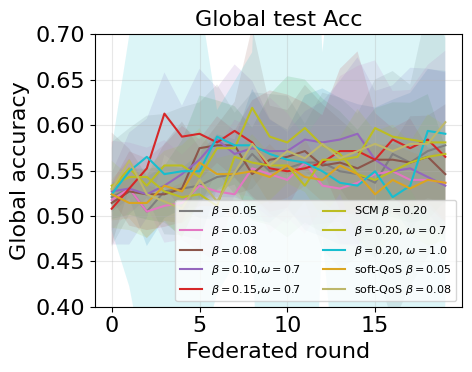

In [17]:
# ============================================================
# 6. PLOT: MEAN ± 95% CI ACCURACY CURVES
# ============================================================


def plot_mean_ci_accuracy(curves_df, save_path):
    plt.figure(figsize=(5,4))

    for scheme, g in curves_df.groupby("scheme"):
        pivot = g.pivot(index="seed", columns="epoch", values="global_acc")
        epochs = pivot.columns.to_numpy()
        arr = pivot.to_numpy(dtype=float)

        mean = np.nanmean(arr, axis=0)
        n = np.sum(~np.isnan(arr), axis=0)
        sd = np.nanstd(arr, axis=0, ddof=1)
        sem = sd / np.sqrt(np.maximum(n, 1))
        ci = np.array([tcrit_95(int(k)) if k > 1 else 0.0 for k in n]) * sem

        label = METHOD_LABELS.get(scheme, scheme)
        color = METHOD_COLORS.get(scheme, None)
        marker = METHOD_MARKERS.get(scheme, "o")


        plt.plot(epochs, mean, label=label, color=color)
        plt.fill_between(epochs, mean - ci, mean + ci, alpha=0.15)

    plt.xlabel("Federated round")
    plt.ylabel("Global accuracy")
    plt.title("Global test Acc", fontsize=PLOT_FONT_SIZE)
    plt.grid(True, alpha=0.3)
  
    
    #plt.close()


    plt.ylim(0.40, 0.70)
    plt.xticks(fontsize=PLOT_FONT_SIZE)
    plt.yticks(fontsize=PLOT_FONT_SIZE)

    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8, loc="lower right", ncols=2)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


plot_mean_ci_accuracy(
    curves_df,
    OUT_DIR / "plot_accuracy_mean_ci.png"
)

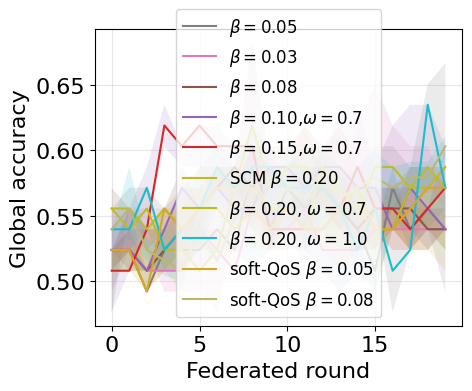

In [18]:
# ============================================================
# 7. PLOT: MEDIAN + IQR ACCURACY CURVES
# ============================================================

def plot_median_iqr_accuracy(curves_df, save_path):
    plt.figure(figsize=PLOT_FIGSIZE)

    for scheme, g in curves_df.groupby("scheme"):
        grouped = g.groupby("epoch")["global_acc"]
        med = grouped.median()
        q1 = grouped.quantile(0.25)
        q3 = grouped.quantile(0.75)
        label = METHOD_LABELS.get(scheme, scheme)
        color = METHOD_COLORS.get(scheme, None)
        marker = METHOD_MARKERS.get(scheme, "o")
        

        plt.plot(med.index, med.values, label=METHOD_LABELS.get(scheme, scheme), color=color)
        plt.fill_between(med.index, q1.values, q3.values, alpha=0.15)

    plt.xlabel("Federated round")
    plt.ylabel("Global accuracy")
    #plt.title("SCM tuning comparison: median + IQR accuracy")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_median_iqr_accuracy(
    curves_df,
    OUT_DIR / "plot_accuracy_median_iqr.png"
)

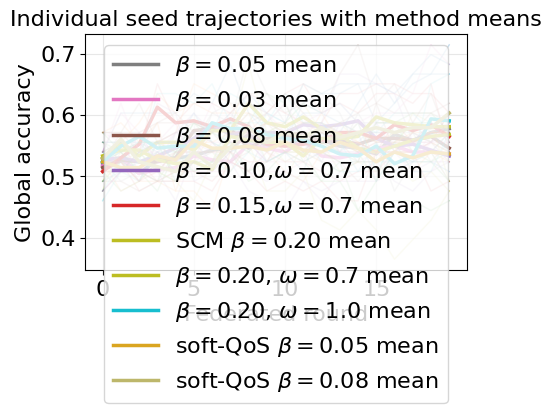

In [19]:
# ============================================================
# 8. PLOT: INDIVIDUAL SEED CURVES
# ============================================================

def plot_individual_seed_curves(curves_df, save_path):
    plt.figure(figsize=PLOT_FIGSIZE)

    for scheme, g in curves_df.groupby("scheme"):
        for seed, sg in g.groupby("seed"):
            plt.plot(sg["epoch"], sg["global_acc"], alpha=0.25, linewidth=1)

        mean_curve = g.groupby("epoch")["global_acc"].mean()
        label = METHOD_LABELS.get(scheme, scheme)
        color = METHOD_COLORS.get(scheme, None)
        marker = METHOD_MARKERS.get(scheme, "o")
        plt.plot(
            mean_curve.index,
            mean_curve.values,
            linewidth=2.5,
            label=f"{METHOD_LABELS.get(scheme, scheme)} mean", color=color
        )

    plt.xlabel("Federated round")
    plt.ylabel("Global accuracy")
    plt.title("Individual seed trajectories with method means")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=PLOT_FONT_SIZE)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_individual_seed_curves(
    curves_df,
    OUT_DIR / "plot_individual_seed_curves.png"
)

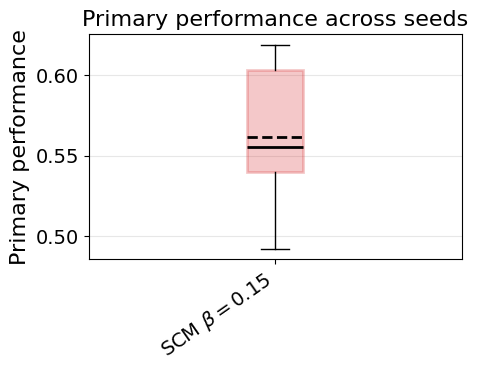

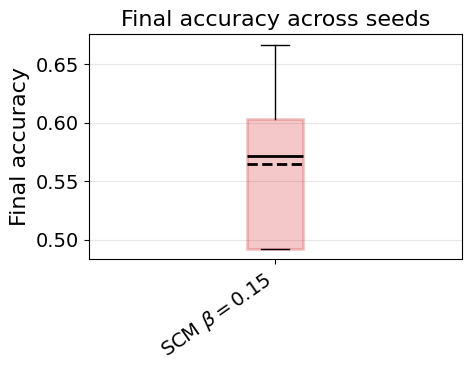

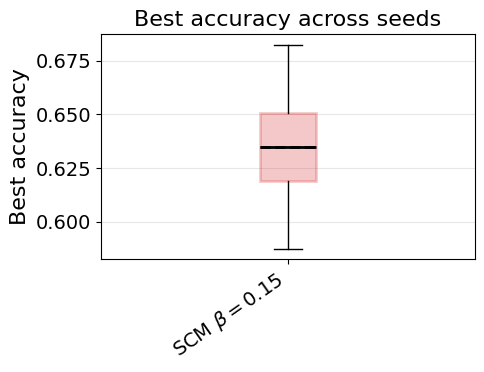

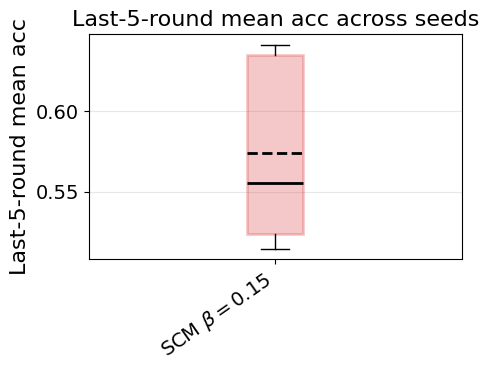

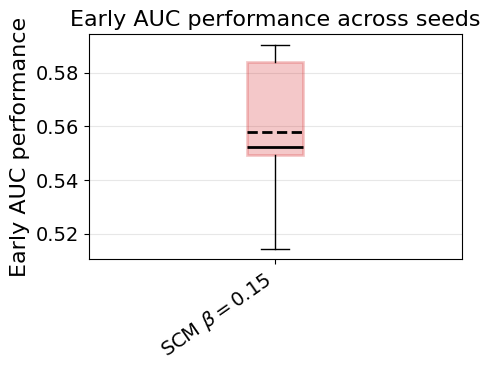

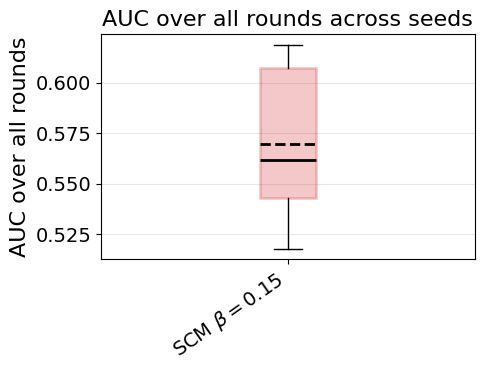

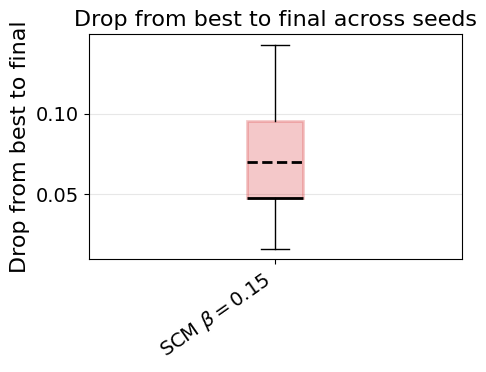

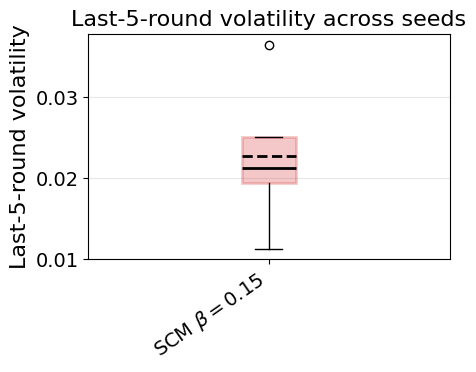

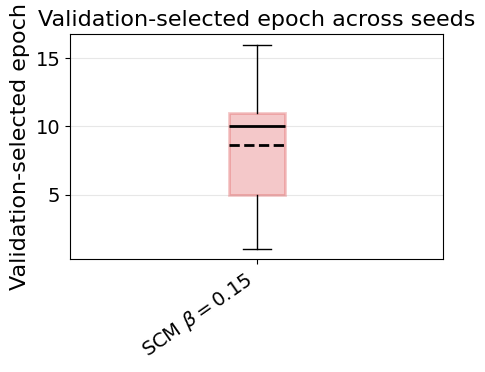

In [20]:
# ============================================================
# 9. BOXPLOTS FOR MAIN METRICS
# ============================================================
# ============================================================
# 9. BOXPLOTS FOR MAIN METRICS
# ============================================================

METHOD_LABELS = {
    "FedAvg": "FedAvg",
    "Conf_A2G_Circular": "A2G",
    "Journal_MP_A2G_QFL_v1": "MP-A2G",
    "Journal_SCM_beta010_relax07": r"SCM $\beta=0.10$",
    "Journal_SCM_beta015_relax07": r"SCM $\beta=0.15$",
    "Journal_SCM_beta020_relax07": r"SCM $\beta=0.20$",
    "Journal_SCM_beta020_relax10": r"SCM $\beta=0.20$",
    "Journal_SCM_A2G_QFLbeta005": r"SCM $\beta=0.05$",
}

SCHEMES_TO_ANALYSE = [
    "Journal_SCM_beta015_relax07",
    "Journal_MP_A2G_QFL_v1",
    "FedAvg",
    "Conf_A2G_Circular",
    
]

def boxplot_metric(summary_by_seed, metric, ylabel, save_path):
    if metric not in summary_by_seed.columns:
        print(f"[SKIP] {metric} not found.")
        return

    df = summary_by_seed[summary_by_seed["scheme"].isin(SCHEMES_TO_ANALYSE)].copy()

    schemes = [s for s in SCHEMES_TO_ANALYSE if s in df["scheme"].unique()]

    data = []
    labels = []
    colors = []

    for s in schemes:
        values = pd.to_numeric(
            df.loc[df["scheme"] == s, metric],
            errors="coerce"
        ).dropna().values

        if len(values) > 0:
            data.append(values)
            labels.append(METHOD_LABELS.get(s, s))
            colors.append(METHOD_COLORS.get(s, "gray"))

    if len(data) == 0:
        print(f"[SKIP] No valid values for {metric}.")
        return

    fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)

    bp = ax.boxplot(
        data,
        patch_artist=True,
        showmeans=True,
        meanline=True
    )

    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.25)
        patch.set_edgecolor(color)
        patch.set_linewidth(2)

    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(2)

    for mean in bp["means"]:
        mean.set_color("black")
        mean.set_linewidth(2)

    ax.set_xticks(np.arange(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=14)

    ax.tick_params(axis="y", labelsize=14)
    ax.set_ylabel(ylabel, fontsize=16)
    ax.set_title(f"{ylabel} across seeds", fontsize=16)
    ax.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
boxplot_metric(summary_by_seed, primary_perf_col, "Primary performance", OUT_DIR / "box_primary_performance.png")
boxplot_metric(summary_by_seed, "final_acc", "Final accuracy", OUT_DIR / "box_final_accuracy.png")
boxplot_metric(summary_by_seed, "best_acc", "Best accuracy", OUT_DIR / "box_best_accuracy.png")
boxplot_metric(summary_by_seed, "last5_mean", "Last-5-round mean acc", OUT_DIR / "box_last5_mean_accuracy.png")
boxplot_metric(summary_by_seed, "auc_first5", "Early AUC performance", OUT_DIR / "box_auc_first5.png")
boxplot_metric(summary_by_seed, "auc_all", "AUC over all rounds", OUT_DIR / "box_auc_all.png")
boxplot_metric(summary_by_seed, "drop_from_best", "Drop from best to final", OUT_DIR / "box_drop_from_best.png")
boxplot_metric(summary_by_seed, "last5_std", "Last-5-round volatility", OUT_DIR / "box_last5_volatility.png")
boxplot_metric(summary_by_seed, "selected_epoch", "Validation-selected epoch", OUT_DIR / "box_selected_epoch.png")

In [72]:
print("Primary metric:", primary_perf_col)
print("\nSchemes in summary_by_seed:")
print(summary_by_seed["scheme"].unique())

print("\nCounts per scheme:")
print(summary_by_seed["scheme"].value_counts())

print("\nMissing values for primary metric:")
print(summary_by_seed.groupby("scheme")[primary_perf_col].apply(lambda x: x.isna().sum()))

print("\nAvailable MP-like schemes:")
print([s for s in summary_by_seed["scheme"].unique() if "MP" in s])

Primary metric: selected_test_acc

Schemes in summary_by_seed:
['Journal_SCM_beta015_relax07' 'Journal_MP_A2G_QFL_v1' 'FedAvg'
 'Conf_A2G_Circular']

Counts per scheme:
scheme
Journal_SCM_beta015_relax07    5
Journal_MP_A2G_QFL_v1          5
FedAvg                         5
Conf_A2G_Circular              5
Name: count, dtype: int64

Missing values for primary metric:
scheme
Conf_A2G_Circular              0
FedAvg                         0
Journal_MP_A2G_QFL_v1          5
Journal_SCM_beta015_relax07    0
Name: selected_test_acc, dtype: int64

Available MP-like schemes:
['Journal_MP_A2G_QFL_v1']


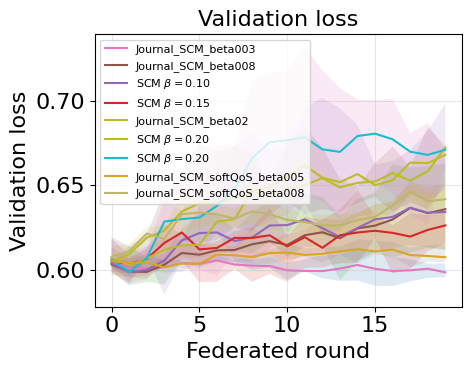

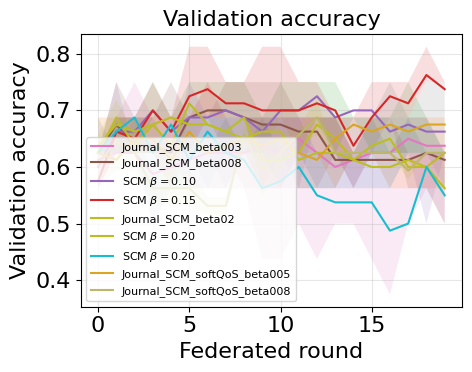

In [22]:
# ============================================================
# 10. VALIDATION LOSS AND VALIDATION ACCURACY PLOTS
# ============================================================

def plot_validation_metric(validation_df, metric, ylabel, save_path):
    if validation_df.empty or metric not in validation_df.columns:
        print(f"[SKIP] {metric} not available in validation curves.")
        return

    plt.figure(figsize=PLOT_FIGSIZE)

    for scheme, g in validation_df.groupby("scheme"):
        g = g.copy()
        g[metric] = pd.to_numeric(g[metric], errors="coerce")

        mean_curve = g.groupby("epoch")[metric].mean()
        q1 = g.groupby("epoch")[metric].quantile(0.25)
        q3 = g.groupby("epoch")[metric].quantile(0.75)
        label = METHOD_LABELS.get(scheme, scheme)
        color = METHOD_COLORS.get(scheme, None)
        marker = METHOD_MARKERS.get(scheme, "o")

        plt.plot(mean_curve.index, mean_curve.values, label=METHOD_LABELS.get(scheme, scheme), color=color)
        plt.fill_between(mean_curve.index, q1.values, q3.values, alpha=0.15)

    plt.xlabel("Federated round")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel}")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


plot_validation_metric(
    validation_df,
    "val_loss",
    "Validation loss",
    OUT_DIR / "plot_validation_loss.png"
)

plot_validation_metric(
    validation_df,
    "val_acc",
    "Validation accuracy",
    OUT_DIR / "plot_validation_accuracy.png"
)

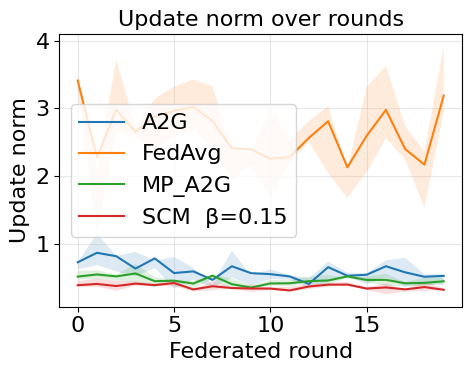

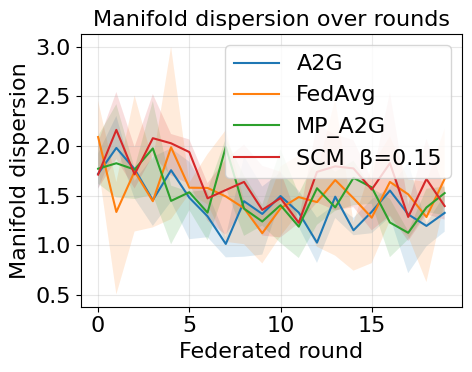

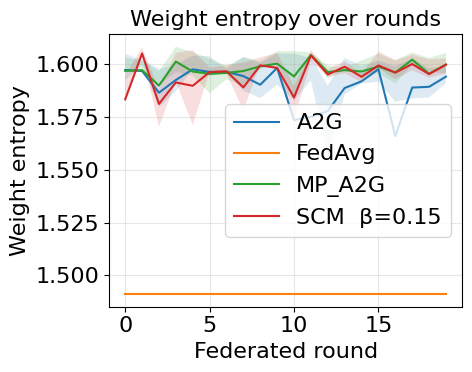

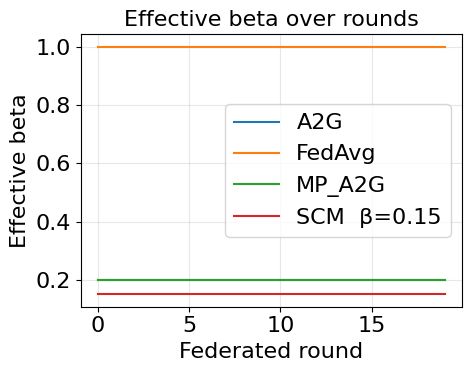

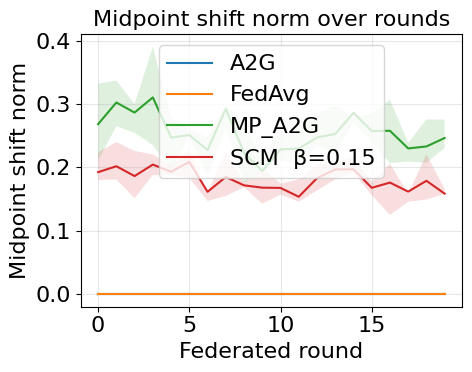

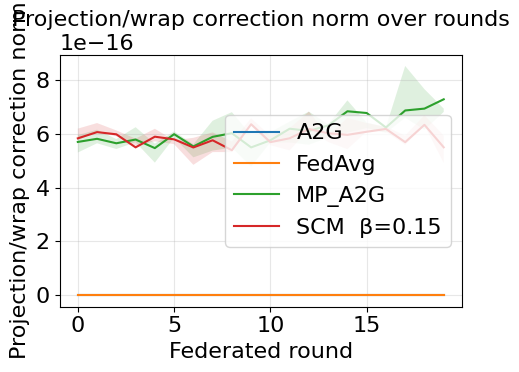

[SKIP] scm_residual not found in round telemetry.
[SKIP] scm_implied_gain not found in round telemetry.
[SKIP] scm_direction_alignment not found in round telemetry.
[SKIP] scm_midpoint_dispersion not found in round telemetry.


In [28]:
# ============================================================
# 11. DIAGNOSTIC CURVES: UPDATE NORM, DISPERSION, SCM METRICS
# ============================================================

def plot_round_diagnostic(rounds_df, metric, ylabel, save_path):
    if rounds_df.empty or metric not in rounds_df.columns:
        print(f"[SKIP] {metric} not found in round telemetry.")
        return

    plt.figure(figsize=PLOT_FIGSIZE)

    for scheme, g in rounds_df.groupby("scheme"):
        g = g.copy()
        g[metric] = pd.to_numeric(g[metric], errors="coerce")

        mean_curve = g.groupby("epoch")[metric].mean()
        q1 = g.groupby("epoch")[metric].quantile(0.25)
        q3 = g.groupby("epoch")[metric].quantile(0.75)

        plt.plot(mean_curve.index, mean_curve.values, label=METHOD_LABELS.get(scheme, scheme))
        plt.fill_between(mean_curve.index, q1.values, q3.values, alpha=0.15)

    plt.xlabel("Federated round")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} over rounds")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=PLOT_FONT_SIZE)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


diagnostic_plot_specs = [
    ("update_norm", "Update norm"),
    ("manifold_dispersion", "Manifold dispersion"),
    ("weight_entropy", "Weight entropy"),
    ("beta_eff", "Effective beta"),
    ("midpoint_shift_norm", "Midpoint shift norm"),
    ("projection_shift_norm", "Projection/wrap correction norm"),
    ("scm_residual", "SCM residual"),
    ("scm_implied_gain", "SCM implied gain"),
    ("scm_direction_alignment", "SCM direction alignment"),
    ("scm_midpoint_dispersion", "SCM midpoint dispersion"),
]

for metric, ylabel in diagnostic_plot_specs:
    plot_round_diagnostic(
        rounds_df,
        metric,
        ylabel,
        OUT_DIR / f"plot_diag_{metric}.png"
    )

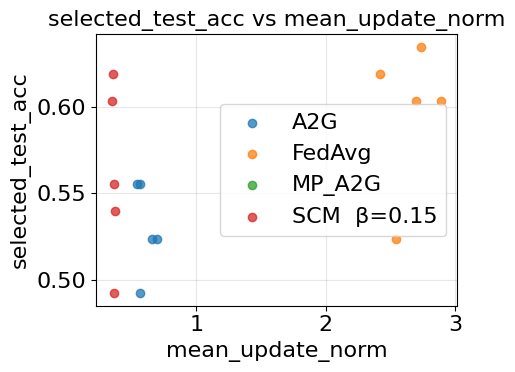

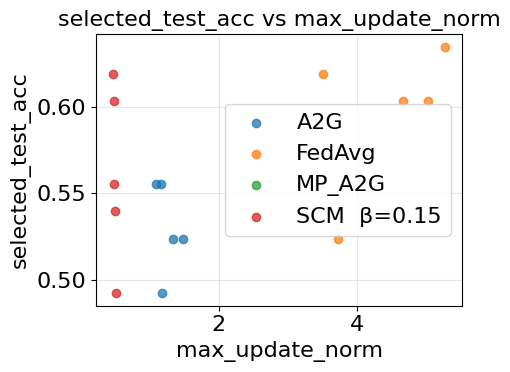

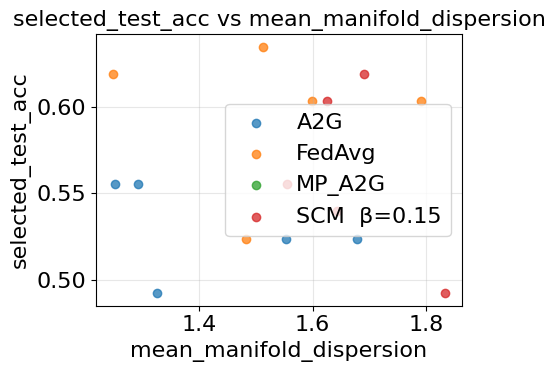

In [43]:
# ============================================================
# 12. MOVEMENT-EFFICIENCY SCATTER PLOTS
# ============================================================

def scatter_metric_vs_performance(summary_by_seed, x_metric, y_metric, save_path):
    if x_metric not in summary_by_seed.columns or y_metric not in summary_by_seed.columns:
        print(f"[SKIP] {x_metric} or {y_metric} missing.")
        return

    plt.figure(figsize=PLOT_FIGSIZE)

    for scheme, g in summary_by_seed.groupby("scheme"):
        x = pd.to_numeric(g[x_metric], errors="coerce")
        y = pd.to_numeric(g[y_metric], errors="coerce")
        mask = ~(x.isna() | y.isna())

        plt.scatter(x[mask], y[mask], label=METHOD_LABELS.get(scheme, scheme), alpha=0.75)

    plt.xlabel(x_metric)
    plt.ylabel(y_metric)
    plt.title(f"{y_metric} vs {x_metric}")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=PLOT_FONT_SIZE)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


scatter_metric_vs_performance(
    summary_by_seed,
    "mean_update_norm",
    primary_perf_col,
    OUT_DIR / "scatter_primary_perf_vs_mean_update_norm.png"
)

scatter_metric_vs_performance(
    summary_by_seed,
    "max_update_norm",
    primary_perf_col,
    OUT_DIR / "scatter_primary_perf_vs_max_update_norm.png"
)

scatter_metric_vs_performance(
    summary_by_seed,
    "mean_manifold_dispersion",
    primary_perf_col,
    OUT_DIR / "scatter_primary_perf_vs_manifold_dispersion.png"
)

In [44]:
# ============================================================
# 13. SELECT BEST SCM CONFIGURATION BY STABILITY-EFFICIENCY SCORE
# ============================================================

score_df = summary_by_seed.copy()

perf_col = primary_perf_col

# Fill missing diagnostic columns safely
for c in ["last5_std", "drop_from_best", "mean_update_norm", "max_update_norm", "mean_manifold_dispersion"]:
    if c not in score_df.columns:
        score_df[c] = np.nan

# Normalize helper: higher is better
def minmax(series, higher_better=True):
    x = pd.to_numeric(series, errors="coerce").astype(float)
    if x.notna().sum() <= 1:
        return pd.Series(np.ones(len(x)) * 0.5, index=x.index)

    lo, hi = x.min(), x.max()
    if abs(hi - lo) < 1e-12:
        return pd.Series(np.ones(len(x)) * 0.5, index=x.index)

    z = (x - lo) / (hi - lo)
    return z if higher_better else 1.0 - z

score_df["score_perf"] = minmax(score_df[perf_col], higher_better=True)
score_df["score_auc_first5"] = minmax(score_df["auc_first5"], higher_better=True)
score_df["score_volatility"] = minmax(score_df["last5_std"], higher_better=False)
score_df["score_drop"] = minmax(score_df["drop_from_best"], higher_better=False)
score_df["score_update"] = minmax(score_df["max_update_norm"], higher_better=False)

score_df["stability_efficiency_score"] = (
    0.35 * score_df["score_perf"]
    + 0.20 * score_df["score_auc_first5"]
    + 0.15 * score_df["score_volatility"]
    + 0.15 * score_df["score_drop"]
    + 0.15 * score_df["score_update"]
)

score_summary = (
    score_df
    .groupby("scheme")["stability_efficiency_score"]
    .agg(["mean", "std", "median"])
    .reset_index()
    .sort_values("mean", ascending=False)
)

score_df.to_csv(OUT_DIR / "score_by_seed.csv", index=False)
score_summary.to_csv(OUT_DIR / "score_summary.csv", index=False)

display(score_summary)

,scheme,mean,std,median
3,Journal_SCM_beta015_relax07,0.716825,0.145446,0.693246
0,Conf_A2G_Circular,0.595691,0.092944,0.576741
1,FedAvg,0.479268,0.095227,0.517730
2,Journal_MP_A2G_QFL_v1,NaN,NaN,NaN


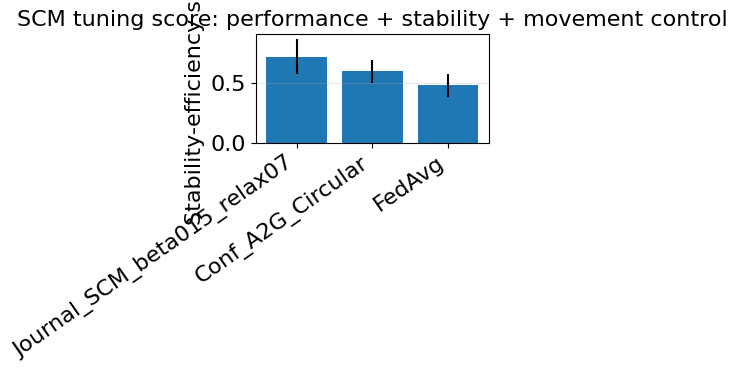

In [47]:
# ============================================================
# 14. PLOT SCORE SUMMARY
# ============================================================

plt.figure(figsize=PLOT_FIGSIZE)
plt.bar(score_summary["scheme"], score_summary["mean"], yerr=score_summary["std"])
plt.xticks(rotation=35, ha="right")
plt.ylabel("Stability-efficiency score")
plt.title("SCM tuning score: performance + stability + movement control")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "bar_stability_efficiency_score.png", dpi=300, bbox_inches="tight")
plt.show()